<a href="https://colab.research.google.com/github/muosaVip/Data-Science/blob/main/patient-bmi-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# استيراد مكتبة pandas
import pandas as pd
import numpy as np

# إنشاء بيانات لـ 20 مريض مع بعض القيم المفقودة
data = {
    "الاسم": [
        "أحمد", "محمد", "سارة", "خالد", "نورة",
        "علي", "ريم", "يوسف", "منى", "عبدالله",
        "فهد", "ليان", "ماجد", "هند", "طارق",
        "رنا", "سلمان", "جود", "ناصر", "شهد"
    ],

    "العمر": [
        25, 30, np.nan, 45, 29,
        38, 27, np.nan, 33, 41,
        22, 26, 35, np.nan, 40,
        31, 28, 24, 37, 29
    ],

    "الطول": [
        170, 175, 160, np.nan, 165,
        180, 158, 172, np.nan, 177,
        169, 162, 174, 159, np.nan,
        168, 181, 163, 176, 161
    ]
}

# إنشاء DataFrame
df = pd.DataFrame(data)

# عرض الجدول قبل الحذف
print("الجدول قبل حذف القيم المفقودة:")
print(df)

# حذف الصفوف التي تحتوي على قيم مفقودة
df_clean = df.dropna()

# عرض الجدول بعد الحذف
print("\nالجدول بعد حذف القيم المفقودة:")
print(df_clean)

الجدول قبل حذف القيم المفقودة:
      الاسم  العمر  الطول
0      أحمد   25.0  170.0
1      محمد   30.0  175.0
2      سارة    NaN  160.0
3      خالد   45.0    NaN
4      نورة   29.0  165.0
5       علي   38.0  180.0
6       ريم   27.0  158.0
7      يوسف    NaN  172.0
8       منى   33.0    NaN
9   عبدالله   41.0  177.0
10      فهد   22.0  169.0
11     ليان   26.0  162.0
12     ماجد   35.0  174.0
13      هند    NaN  159.0
14     طارق   40.0    NaN
15      رنا   31.0  168.0
16    سلمان   28.0  181.0
17      جود   24.0  163.0
18     ناصر   37.0  176.0
19      شهد   29.0  161.0

الجدول بعد حذف القيم المفقودة:
      الاسم  العمر  الطول
0      أحمد   25.0  170.0
1      محمد   30.0  175.0
4      نورة   29.0  165.0
5       علي   38.0  180.0
6       ريم   27.0  158.0
9   عبدالله   41.0  177.0
10      فهد   22.0  169.0
11     ليان   26.0  162.0
12     ماجد   35.0  174.0
15      رنا   31.0  168.0
16    سلمان   28.0  181.0
17      جود   24.0  163.0
18     ناصر   37.0  176.0
19      شهد   29.0  161.0


In [ ]:
# استيراد المكتبات
import pandas as pd

# إنشاء جدول المرضى
data = {
    "الاسم": ["أحمد", "محمد", "سارة", "خالد", "نورة",
             "علي", "ريم", "يوسف", "منى", "عبدالله"],

    "العمر": [25, 30, 42, 45, 29, 38, 27, 50, 33, 41],

    "الطول": [170, 175, 160, 180, 165, 178, 158, 172, 168, 177],  # بالسنتيمتر

    "الوزن": [70, 80, 55, 95, 60, 85, 50, 78, 65, 90]   # بالكيلو
}

# تحويل البيانات إلى جدول
df = pd.DataFrame(data)

# -----------------------------
# إضافة عمود BMI
# -----------------------------

# تحويل الطول من سم إلى متر
df["الطول_بالمتر"] = df["الطول"] / 100

# حساب BMI = الوزن ÷ (الطول بالمتر)^2
df["BMI"] = df["الوزن"] / (df["الطول_بالمتر"] ** 2)

# تقريب الرقم إلى منزلتين عشريتين
df["BMI"] = df["BMI"].round(2)

# حذف العمود المؤقت
df.drop("الطول_بالمتر", axis=1, inplace=True)

print("الجدول بعد إضافة BMI:")
print(df)

# -----------------------------
# حذف المرضى أكبر من 40 سنة
# -----------------------------

df = df[df["العمر"] <= 40]

print("\nالجدول بعد حذف المرضى الأكبر من 40 سنة:")
print(df)

الجدول بعد إضافة BMI:
     الاسم  العمر  الطول  الوزن    BMI
0     أحمد     25    170     70  24.22
1     محمد     30    175     80  26.12
2     سارة     42    160     55  21.48
3     خالد     45    180     95  29.32
4     نورة     29    165     60  22.04
5      علي     38    178     85  26.83
6      ريم     27    158     50  20.03
7     يوسف     50    172     78  26.37
8      منى     33    168     65  23.03
9  عبدالله     41    177     90  28.73

الجدول بعد حذف المرضى الأكبر من 40 سنة:
  الاسم  العمر  الطول  الوزن    BMI
0  أحمد     25    170     70  24.22
1  محمد     30    175     80  26.12
4  نورة     29    165     60  22.04
5   علي     38    178     85  26.83
6   ريم     27    158     50  20.03
8   منى     33    168     65  23.03


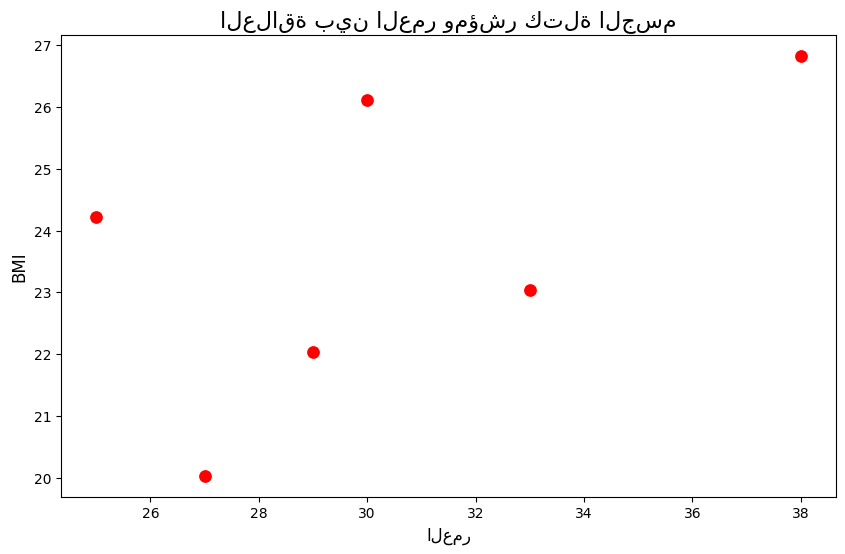

In [ ]:
# استيراد المكتبات
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط حجم الرسم
plt.figure(figsize=(10,6))

# رسم Scatter Plot بين العمر و BMI
sns.scatterplot(
    data=df,
    x="العمر",
    y="BMI",
    color="red",
    s=100
)

# عنوان الرسم
plt.title("العلاقة بين العمر ومؤشر كتلة الجسم", fontsize=16)

# أسماء المحاور
plt.xlabel("العمر", fontsize=12)
plt.ylabel("BMI", fontsize=12)

# إظهار الرسم
plt.show()

In [ ]:
# استيراد مكتبة Linear Regression
from sklearn.linear_model import LinearRegression

# -----------------------------
# تجهيز البيانات
# -----------------------------

# العمر = المتغير المستقل X
X = df[["العمر"]]

# BMI = المتغير التابع y
y = df["BMI"]

# -----------------------------
# إنشاء النموذج وتدريبه
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# التنبؤ لشخص عمره 35 سنة
# -----------------------------
predicted_bmi = model.predict([[35]])

# -----------------------------
# طباعة النتيجة
# -----------------------------
print("القيمة المتوقعة لمؤشر كتلة الجسم (BMI) لشخص عمره 35 سنة هي:")
print(round(predicted_bmi[0], 2))

القيمة المتوقعة لمؤشر كتلة الجسم (BMI) لشخص عمره 35 سنة هي:
25.15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# قيمة BMI المتوقعة
bmi = 25.15

# شرط if
if bmi > 25:
    print("ينصح باتباع نظام غذائي")
else:
    print("الوزن المثالي")

ينصح باتباع نظام غذائي


✅ ما تم إنجازه (الحالة الراهنة)
لقد انتهينا من مرحلة التأسيس والتحليل الاستكشافي، وهي تشمل:
1.	إتقان الأدوات (🛠️): التعامل بمرونة مع المكتبات الأساسية (Python, Pandas, NumPy) لمعالجة الجداول والمصفوفات.
2.	تنظيف البيانات (📊): القدرة على التعامل مع القيم المفقودة، تصفية البيانات، وتجهيزها لتكون صالحة للتحليل.
3.	استخراج الرؤى (💡): تحويل الأرقام الصماء إلى تصورات بيانية (Matplotlib) تعكس واقع البيانات وتدعم اتخاذ القرار الأولي.